Mounted at /content/drive
[INFO] Google Drive mounted successfully.
[INFO] Output directory confirmed: /content/drive/MyDrive/KBS_Paper/Outputs/3_Baselines_KBS/

[INFO] ── Loading datasets ──────────────────────────────────────────
  [TRAIN] shape=(12477, 722) | start=2018-07-10 06:00:00 | end=2022-10-17 06:00:00 | Hs range=[0.000, 3.463] m
  [OOS] shape=(5605, 722) | start=2022-10-18 09:00:00 | end=2024-09-18 06:00:00 | Hs range=[0.000, 4.297] m

[INFO] ── Computing Multi-Horizon Baselines ─────────────────────────

  [Horizon +3h] ─────────────────────────────────────────
    [Train/Val]  Persistence | RMSE=0.2551 m | MAE=0.0943 m | R²=0.1847 | MAPE=33373.82%
    [Train/Val]      SMA-12h | RMSE=0.2256 m | MAE=0.1142 m | R²=0.3622 | MAPE=55624.26%
    [OOS]  Persistence | RMSE=0.2932 m | MAE=0.0885 m | R²=0.0586 | MAPE=4669.68%
    [OOS]      SMA-12h | RMSE=0.2540 m | MAE=0.1132 m | R²=0.2935 | MAPE=11880.92%

  [Horizon +6h] ─────────────────────────────────────────
    [Train/Val]  

  [SAVED] /content/drive/MyDrive/KBS_Paper/Outputs/3_Baselines_KBS/Fig_Density_Scatter_Persist_OOS_6h.png


  [SAVED] /content/drive/MyDrive/KBS_Paper/Outputs/3_Baselines_KBS/Fig_Density_Scatter_Persist_OOS_6h.tiff


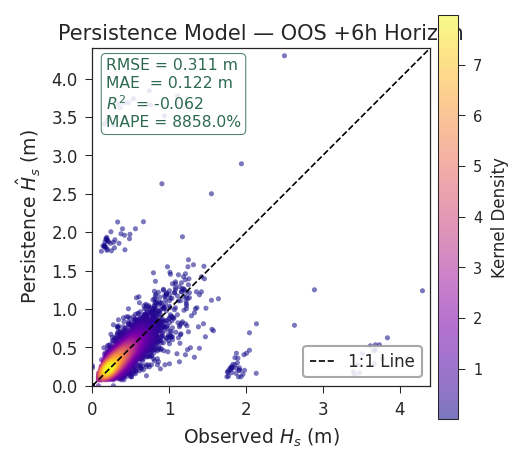

  [STORM] Peak Hs=4.30 m at 2024-04-16 09:00:00 | window=2024-04-09 → 2024-04-23 (113 records)
  [SAVED] /content/drive/MyDrive/KBS_Paper/Outputs/3_Baselines_KBS/Fig_Storm_TimeSeries_OOS_6h.png
  [SAVED] /content/drive/MyDrive/KBS_Paper/Outputs/3_Baselines_KBS/Fig_Storm_TimeSeries_OOS_6h.tiff


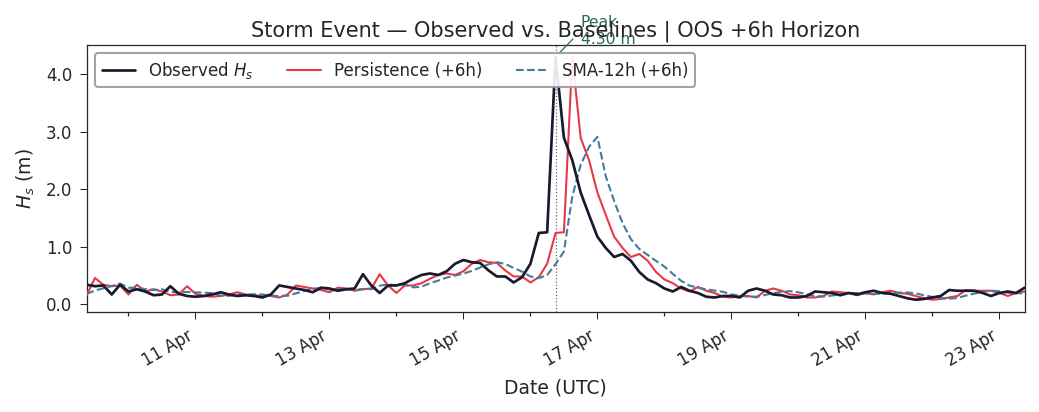


  BASELINE PIPELINE COMPLETE
  Output directory : /content/drive/MyDrive/KBS_Paper/Outputs/3_Baselines_KBS/
  Metrics CSV      : baselines_metrics_summary.csv
  Train preds CSV  : baselines_train_predictions.csv
  OOS preds CSV    : baselines_oos_predictions.csv
  Figures          : Fig_Density_Scatter_Persist_OOS_6h.[png|tiff]
                     Fig_Storm_TimeSeries_OOS_6h.[png|tiff]



In [1]:
# =============================================================================
# SCRIPT: 3_Statistical_Baselines_KBS.py
# PURPOSE: Establish statistical baselines (Persistence & SMA) for a
#          multi-horizon coastal wave forecasting system.
# TARGET JOURNAL: Knowledge-Based Systems (KBS) — Q1 Elsevier
# AUTHOR: [Your Name]
# =============================================================================

# ---------------------------------------------------------------------------
# 0. ENVIRONMENT SETUP & IMPORTS
# ---------------------------------------------------------------------------
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import gaussian_kde

warnings.filterwarnings("ignore")

# Mount Google Drive (comment out if already mounted)
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    print("[INFO] Google Drive mounted successfully.")
except Exception:
    print("[INFO] Running outside Colab or Drive already mounted.")

# ---------------------------------------------------------------------------
# 1. PATH CONFIGURATION
# ---------------------------------------------------------------------------
INPUT_DIR  = "/content/drive/MyDrive/KBS_Paper/Outputs/2_Feature_Engineering_KBS/"
OUTPUT_DIR = "/content/drive/MyDrive/KBS_Paper/Outputs/3_Baselines_KBS/"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"[INFO] Output directory confirmed: {OUTPUT_DIR}")

# ---------------------------------------------------------------------------
# 2. GLOBAL CONSTANTS
# ---------------------------------------------------------------------------
HORIZONS_H      = [3, 6, 12, 24]          # Forecast horizons in hours
TIME_RES_H      = 3                        # Dataset temporal resolution (hours)
SMA_WINDOW      = 4                        # 4 × 3h = 12-hour rolling window
TARGET_COL      = "target_buoy_hs"         # Wave height column
EPSILON         = 1e-6                     # Guard for MAPE division
PLOT_HORIZON_H  = 6                        # Horizon used for manuscript figures
STORM_WINDOW_D  = 14                       # Days to slice around storm peak
DPI_OUT         = 600                      # Export resolution

# ---------------------------------------------------------------------------
# 3. KBS / ELSEVIER MATPLOTLIB STYLE CONFIGURATION
# ---------------------------------------------------------------------------
FONT_FAMILY   = "Times New Roman"
FONT_SIZE_AX  = 9
FONT_SIZE_TIT = 10
FONT_SIZE_LBL = 9
FONT_SIZE_TK  = 8
COLOR_ACTUAL  = "#1a1a2e"          # Deep navy — Actual
COLOR_PERSIST = "#e63946"          # Vivid red — Persistence
COLOR_SMA     = "#457b9d"          # Steel blue — SMA
COLOR_ANNOT   = "#2d6a4f"          # Forest green — annotations
LINE_W        = 1.0
SCATTER_S     = 6
SCATTER_ALPHA = 0.55
FIG_W_SINGLE  = 3.5                # Single-column (inches) for KBS
FIG_W_DOUBLE  = 7.0                # Double-column (inches)

matplotlib.rcParams.update({
    "font.family"        : FONT_FAMILY,
    "font.size"          : FONT_SIZE_AX,
    "axes.titlesize"     : FONT_SIZE_TIT,
    "axes.labelsize"     : FONT_SIZE_LBL,
    "xtick.labelsize"    : FONT_SIZE_TK,
    "ytick.labelsize"    : FONT_SIZE_TK,
    "legend.fontsize"    : FONT_SIZE_TK,
    "axes.linewidth"     : 0.6,
    "xtick.major.width"  : 0.5,
    "ytick.major.width"  : 0.5,
    "xtick.direction"    : "in",
    "ytick.direction"    : "in",
    "xtick.top"          : True,
    "ytick.right"        : True,
    "figure.dpi"         : 150,
    "savefig.dpi"        : DPI_OUT,
    "pdf.fonttype"       : 42,
    "ps.fonttype"        : 42,
})
sns.set_style("ticks")

# ---------------------------------------------------------------------------
# 4. DATA LOADING
# ---------------------------------------------------------------------------
print("\n[INFO] ── Loading datasets ──────────────────────────────────────────")

def load_and_prep(filepath: str, label: str) -> pd.DataFrame:
    """Load CSV, parse 'time' column, sort chronologically, and set as index."""
    df = pd.read_csv(filepath)
    if "time" not in df.columns:
        raise ValueError(f"'time' column not found in {filepath}.")
    df["time"] = pd.to_datetime(df["time"])
    df = df.sort_values("time").set_index("time")
    if TARGET_COL not in df.columns:
        raise ValueError(f"'{TARGET_COL}' column not found in {filepath}.")
    print(f"  [{label}] shape={df.shape} | "
          f"start={df.index.min()} | end={df.index.max()} | "
          f"Hs range=[{df[TARGET_COL].min():.3f}, {df[TARGET_COL].max():.3f}] m")
    return df

df_train = load_and_prep(os.path.join(INPUT_DIR, "X_train_KBS.csv"), "TRAIN")
df_oos   = load_and_prep(os.path.join(INPUT_DIR, "X_oos_KBS.csv"),   "OOS")

# ---------------------------------------------------------------------------
# 5. METRIC UTILITY FUNCTIONS
# ---------------------------------------------------------------------------
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """Return RMSE, MAE, R², MAPE as a dictionary."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + EPSILON))) * 100.0
    return {"RMSE": round(rmse, 4),
            "MAE" : round(mae,  4),
            "R2"  : round(r2,   4),
            "MAPE": round(mape, 4)}


def evaluate_horizon(df: pd.DataFrame, h: int) -> tuple:
    """
    For a given dataframe and horizon h (hours), compute:
      - actual     : shifted target (ground truth at t+h)
      - persist    : Hs at t (persistence baseline)
      - sma        : 12-hour rolling mean at t (SMA baseline)
    Returns clean DataFrame after dropping NaNs.
    """
    step = int(h / TIME_RES_H)          # Number of time-steps

    tmp = pd.DataFrame(index=df.index)
    tmp["actual_hs"]       = df[TARGET_COL].shift(-step)   # future truth
    tmp["persist_pred_hs"] = df[TARGET_COL]                 # current value
    tmp["sma_pred_hs"]     = (
        df[TARGET_COL]
        .rolling(window=SMA_WINDOW, min_periods=SMA_WINDOW)
        .mean()
    )

    tmp = tmp.dropna()
    return tmp

# ---------------------------------------------------------------------------
# 6. MULTI-HORIZON BASELINE LOOP
# ---------------------------------------------------------------------------
print("\n[INFO] ── Computing Multi-Horizon Baselines ─────────────────────────")

metrics_records   = []
train_pred_frames = []
oos_pred_frames   = []

for h in HORIZONS_H:
    print(f"\n  [Horizon +{h}h] ─────────────────────────────────────────")

    for df_src, label in [(df_train, "Train/Val"), (df_oos, "OOS")]:
        tmp = evaluate_horizon(df_src, h)

        y_true   = tmp["actual_hs"].values
        y_persist = tmp["persist_pred_hs"].values
        y_sma     = tmp["sma_pred_hs"].values

        # ── Metrics ──────────────────────────────────────────────────────
        met_p = compute_metrics(y_true, y_persist)
        met_s = compute_metrics(y_true, y_sma)

        for model, met in [("Persistence", met_p), ("SMA-12h", met_s)]:
            row = {"Split": label, "Horizon_h": h, "Model": model, **met}
            metrics_records.append(row)
            print(f"    [{label}] {model:>12s} | "
                  f"RMSE={met['RMSE']:.4f} m | "
                  f"MAE={met['MAE']:.4f} m | "
                  f"R²={met['R2']:.4f} | "
                  f"MAPE={met['MAPE']:.2f}%")

        # ── DSS-ready prediction frame ────────────────────────────────────
        frame = tmp.reset_index().rename(columns={"time": "time"})
        frame["split"]        = label
        frame["horizon_hours"] = h
        frame = frame[["time", "split", "horizon_hours",
                        "actual_hs", "persist_pred_hs", "sma_pred_hs"]]

        if label == "Train/Val":
            train_pred_frames.append(frame)
        else:
            oos_pred_frames.append(frame)

# ---------------------------------------------------------------------------
# 7. EXPORT: METRICS SUMMARY & PREDICTION LONG-FORMAT CSVs
# ---------------------------------------------------------------------------
print("\n[INFO] ── Exporting CSVs ─────────────────────────────────────────────")

# 7a. Metrics summary
metrics_df = pd.DataFrame(metrics_records)
metrics_df = metrics_df[["Split", "Model", "Horizon_h",
                          "RMSE", "MAE", "R2", "MAPE"]]
metrics_path = os.path.join(OUTPUT_DIR, "baselines_metrics_summary.csv")
metrics_df.to_csv(metrics_path, index=False)
print(f"  [SAVED] {metrics_path}")
print(metrics_df.to_string(index=False))

# 7b. Prediction frames (long format)
train_preds_df = pd.concat(train_pred_frames, ignore_index=True)
oos_preds_df   = pd.concat(oos_pred_frames,   ignore_index=True)

train_pred_path = os.path.join(OUTPUT_DIR, "baselines_train_predictions.csv")
oos_pred_path   = os.path.join(OUTPUT_DIR, "baselines_oos_predictions.csv")

train_preds_df.to_csv(train_pred_path, index=False)
oos_preds_df.to_csv(oos_pred_path,   index=False)
print(f"  [SAVED] {train_pred_path}  ({len(train_preds_df):,} rows)")
print(f"  [SAVED] {oos_pred_path}    ({len(oos_preds_df):,} rows)")

# ---------------------------------------------------------------------------
# 8. MANUSCRIPT FIGURES — OOS SET, +6h HORIZON
# ---------------------------------------------------------------------------
print(f"\n[INFO] ── Generating manuscript figures (+{PLOT_HORIZON_H}h, OOS) ─────")

# ── Extract the +6h OOS slice ─────────────────────────────────────────────
plot_df = oos_preds_df[oos_preds_df["horizon_hours"] == PLOT_HORIZON_H].copy()
plot_df["time"] = pd.to_datetime(plot_df["time"])
plot_df = plot_df.sort_values("time").set_index("time")

y_act  = plot_df["actual_hs"].values
y_per  = plot_df["persist_pred_hs"].values
y_sma  = plot_df["sma_pred_hs"].values

# ---------------------------------------------------------------------------
# 8A. DENSITY SCATTER PLOT — Persistence: Actual vs Predicted
# ---------------------------------------------------------------------------
def save_fig(fig, stem: str):
    """Save figure as high-res PNG and TIFF to OUTPUT_DIR."""
    for ext in ["png", "tiff"]:
        path = os.path.join(OUTPUT_DIR, f"{stem}.{ext}")
        fig.savefig(path, dpi=DPI_OUT, bbox_inches="tight",
                    format=ext, pil_kwargs={"compression": "tiff_lzw"} if ext=="tiff" else {})
        print(f"  [SAVED] {path}")


# ── KDE-based density for scatter coloring ───────────────────────────────
xy  = np.vstack([y_act, y_per])
kde = gaussian_kde(xy)
z   = kde(xy)
idx = z.argsort()                     # plot densest points on top
x_s, y_s, z_s = y_act[idx], y_per[idx], z[idx]

# ── Identity-line limits ──────────────────────────────────────────────────
lim_lo = max(0, min(y_act.min(), y_per.min()) - 0.1)
lim_hi = max(y_act.max(), y_per.max()) + 0.1

fig1, ax1 = plt.subplots(figsize=(FIG_W_SINGLE, FIG_W_SINGLE))

sc = ax1.scatter(x_s, y_s,
                 c=z_s,
                 s=SCATTER_S,
                 alpha=SCATTER_ALPHA,
                 cmap="plasma",
                 linewidths=0,
                 rasterized=True)

ax1.plot([lim_lo, lim_hi], [lim_lo, lim_hi],
         color="k", lw=0.8, ls="--", label="1:1 Line", zorder=5)

cbar = fig1.colorbar(sc, ax=ax1, pad=0.02)
cbar.set_label("Kernel Density", fontsize=FONT_SIZE_TK)
cbar.ax.tick_params(labelsize=FONT_SIZE_TK - 1, width=0.5)
cbar.outline.set_linewidth(0.5)

# Retrieve +6h OOS persistence metrics for annotation
row_p6 = metrics_df[
    (metrics_df["Split"] == "OOS") &
    (metrics_df["Horizon_h"] == PLOT_HORIZON_H) &
    (metrics_df["Model"] == "Persistence")
].iloc[0]

stats_txt = (f"RMSE = {row_p6['RMSE']:.3f} m\n"
             f"MAE  = {row_p6['MAE']:.3f} m\n"
             f"$R^2$  = {row_p6['R2']:.3f}\n"
             f"MAPE = {row_p6['MAPE']:.1f}%")
ax1.text(0.04, 0.97, stats_txt,
         transform=ax1.transAxes,
         va="top", ha="left",
         fontsize=FONT_SIZE_TK - 0.5,
         color=COLOR_ANNOT,
         fontfamily=FONT_FAMILY,
         bbox=dict(boxstyle="round,pad=0.3", fc="white",
                   ec=COLOR_ANNOT, lw=0.5, alpha=0.85))

ax1.set_xlim(lim_lo, lim_hi)
ax1.set_ylim(lim_lo, lim_hi)
ax1.set_aspect("equal")
ax1.set_xlabel(r"Observed $H_s$ (m)")
ax1.set_ylabel(r"Persistence $\hat{H}_s$ (m)")
ax1.set_title(f"Persistence Model — OOS +{PLOT_HORIZON_H}h Horizon", pad=4)
ax1.legend(loc="lower right", frameon=True, framealpha=0.85,
           edgecolor="0.6", handlelength=1.5)
sns.despine(ax=ax1, top=False, right=False)

save_fig(fig1, "Fig_Density_Scatter_Persist_OOS_6h")
plt.show()
plt.close(fig1)

# ---------------------------------------------------------------------------
# 8B. STORM PEAK TIME-SERIES OVERLAY
# ---------------------------------------------------------------------------
# ── Locate storm peak and slice ±7 days (14-day window) ──────────────────
peak_time  = plot_df["actual_hs"].idxmax()
half_win   = pd.Timedelta(days=STORM_WINDOW_D / 2)
storm_start = peak_time - half_win
storm_end   = peak_time + half_win

storm_df = plot_df.loc[storm_start:storm_end].copy()
print(f"  [STORM] Peak Hs={storm_df['actual_hs'].max():.2f} m "
      f"at {peak_time} | "
      f"window={storm_start.date()} → {storm_end.date()} "
      f"({len(storm_df)} records)")

fig2, ax2 = plt.subplots(figsize=(FIG_W_DOUBLE, 2.8))

ax2.plot(storm_df.index, storm_df["actual_hs"],
         color=COLOR_ACTUAL, lw=LINE_W + 0.3,
         label=r"Observed $H_s$", zorder=4)

ax2.plot(storm_df.index, storm_df["persist_pred_hs"],
         color=COLOR_PERSIST, lw=LINE_W, ls="-",
         label=f"Persistence (+{PLOT_HORIZON_H}h)", zorder=3)

ax2.plot(storm_df.index, storm_df["sma_pred_hs"],
         color=COLOR_SMA, lw=LINE_W, ls="--",
         label=f"SMA-12h (+{PLOT_HORIZON_H}h)", zorder=3)

# Annotate storm peak
ax2.axvline(peak_time, color="0.4", lw=0.6, ls=":", zorder=2)
ax2.annotate(f"Peak\n{storm_df['actual_hs'].max():.2f} m",
             xy=(peak_time, storm_df["actual_hs"].max()),
             xytext=(12, 6), textcoords="offset points",
             fontsize=FONT_SIZE_TK - 0.5,
             color=COLOR_ANNOT,
             arrowprops=dict(arrowstyle="-", color=COLOR_ANNOT,
                             lw=0.6, relpos=(0, 0.5)))

ax2.set_xlabel("Date (UTC)")
ax2.set_ylabel(r"$H_s$ (m)")
ax2.set_title(f"Storm Event — Observed vs. Baselines | OOS +{PLOT_HORIZON_H}h Horizon",
              pad=4)
ax2.set_xlim(storm_df.index[0], storm_df.index[-1])
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax2.xaxis.set_minor_locator(mdates.DayLocator(interval=1))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax2.legend(loc="upper left", ncol=3, frameon=True,
           framealpha=0.9, edgecolor="0.6", handlelength=2.0)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
sns.despine(ax=ax2, top=False, right=False)
fig2.tight_layout()

save_fig(fig2, "Fig_Storm_TimeSeries_OOS_6h")
plt.show()
plt.close(fig2)

# ---------------------------------------------------------------------------
# 9. FINAL EXECUTION SUMMARY
# ---------------------------------------------------------------------------
print("\n" + "="*72)
print("  BASELINE PIPELINE COMPLETE")
print("="*72)
print(f"  Output directory : {OUTPUT_DIR}")
print(f"  Metrics CSV      : baselines_metrics_summary.csv")
print(f"  Train preds CSV  : baselines_train_predictions.csv")
print(f"  OOS preds CSV    : baselines_oos_predictions.csv")
print(f"  Figures          : Fig_Density_Scatter_Persist_OOS_6h.[png|tiff]")
print(f"                     Fig_Storm_TimeSeries_OOS_6h.[png|tiff]")
print("="*72 + "\n")